# Grid2Op observations
Grid2Op returns instances of type CompleteObservations for the agents to work with.

In [1]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent.parent  # Adjusts for notebook being in src/visualization/
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/grid2op/MakeEnv/Make.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Normally observation are of type: CompleteObservation_l2rpn_case14_sandbox


AttributeError: 'FigureCanvasAgg' object has no attribute 'tostring_rgb'

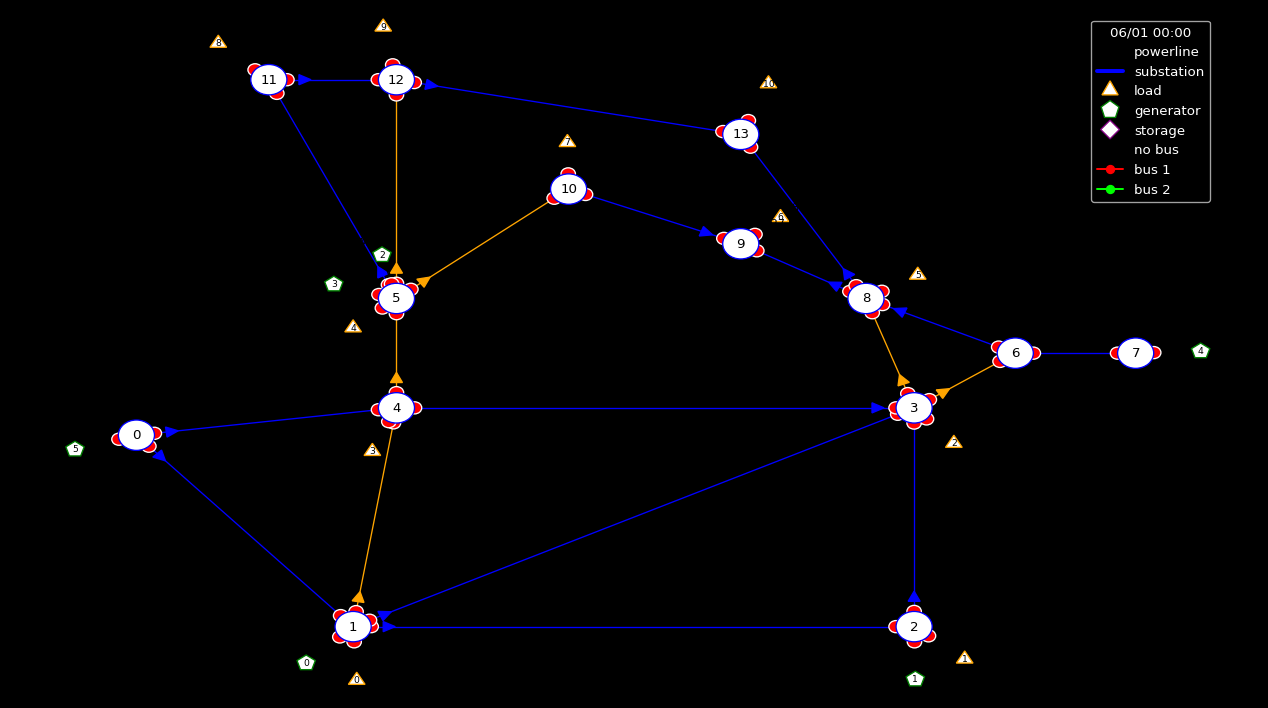

In [1]:
import grid2op
from grid2op.gym_compat import GymEnv

env_name = "l2rpn_case14_sandbox"
env = grid2op.make(env_name)
obs = env.reset()
print(f"Normally observation are of type: {obs.__class__.__name__}")
env.attach_renderer()
env.render()

This is not directly compatible with RL. Therefore, they provide wrappers that convert these instances to Gymnasium like observation spaces like Dict, Box, etc. Typically, we can just use the GymEnv wrapper:

In [2]:
gym_env = GymEnv(env)
obs = gym_env.reset()
print(f"Observation compatible with gymnasium:\n{obs}")

Observation compatible with gymnasium:
(OrderedDict({'_shunt_bus': array([1], dtype=int32), '_shunt_p': array([0.], dtype=float32), '_shunt_q': array([-21.150887], dtype=float32), '_shunt_v': array([21.101702], dtype=float32), 'a_ex': array([ 172.97667 ,  153.61761 ,  101.20946 ,  163.08243 ,  135.81807 ,
         71.14077 ,  123.353935,  371.92596 ,  251.86035 ,  627.2592  ,
         73.27256 ,  228.36478 ,  262.27246 ,   71.38806 ,  279.96725 ,
       1161.3689  ,  393.55307 ,  899.84863 , 1063.1875  ,  973.6984  ],
      dtype=float32), 'a_or': array([180.04834 , 153.76129 , 105.55805 , 162.71709 , 135.5985  ,
        68.3029  , 123.353935, 371.92596 , 251.86035 , 627.2592  ,
        73.27256 , 228.36478 , 262.27246 ,  71.38806 , 279.96725 ,
       120.47038 ,  58.86138 , 139.92795 , 911.3036  , 681.58887 ],
      dtype=float32), 'actual_dispatch': array([0., 0., 0., 0., 0., 0.], dtype=float32), 'attention_budget': array([0.], dtype=float32), 'current_step': array([0], dtype=int32),

# Graph Observations
The above observation is a dict and therefore part of the Dict observation space of gymnasium. For our purposes we want to observe the powergrid as graph. We want to have a set of nodes and edges each having some features. This is not implemented by default in grid2op. For this reason, I implemented a custom observation space that represents the powergrid as a graph in the following way:
- Nodes: Connections between buses and powerline-endpoints/loads/generators
- Edges: Connect both endpoints of the same powerline. Connect endpoints of different powerlines if they are connected to the same substation and the same bus.

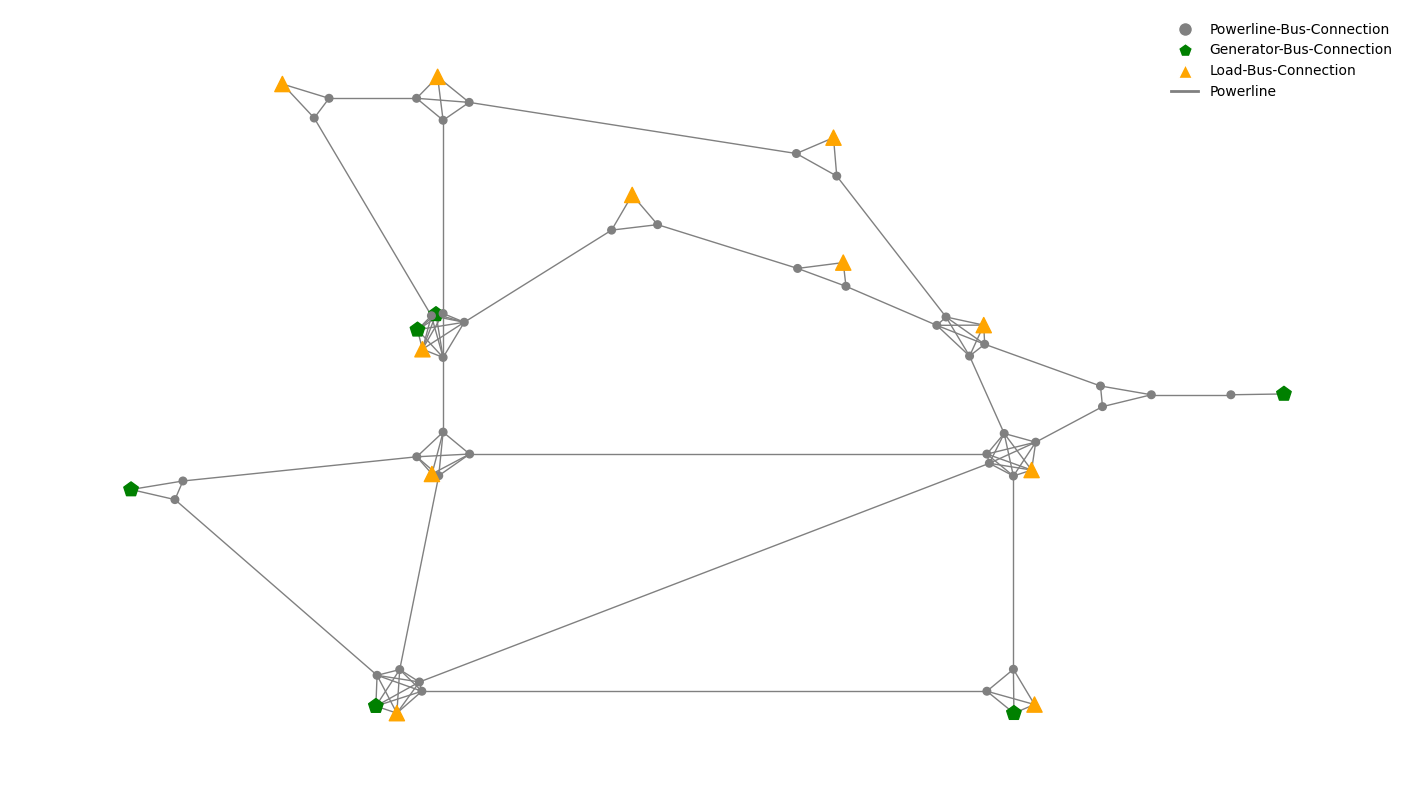

In [3]:
from src.visualization import visualize_graph, get_node_styles, PlottingArgs
from src.common.observation_space import BusConnectivityGraphObsSpace, EDGE_INDEX

env = grid2op.make(env_name)
g2op_obs = env.reset()
obs_space = BusConnectivityGraphObsSpace(env.observation_space)
edge_index = obs_space.to_gym(g2op_obs)[EDGE_INDEX]
plotting_args = PlottingArgs(
    num_nodes=obs_space.num_nodes,
    powerline_edge_index=edge_index,
    node_styles=get_node_styles(env, obs_space.__class__)
)
fig = visualize_graph(plotting_args)
fig.show()

We can use the observation space like this:


In [4]:
from src.common.env import G2OpGymEnv

graph_env = G2OpGymEnv(env_name, obs_space_creation=lambda e: BusConnectivityGraphObsSpace(e.observation_space))
obs, _ = graph_env.reset()

The returned observations follow the Dict observation space scheme by gymnasium and include the following information:
## Node features
In this representation edges don't have features. Node features include:
- active/reactive power
- voltage + voltage angle
- current
- rho

The node features are stored as an array of shape `[num_nodes, num_features]`.

In [5]:
from src.common.observation_space import NODES
print(f"Shape: {obs[NODES].shape}")
obs[NODES]

Shape: (57, 8)


array([[ 0.00000000e+00,  0.00000000e+00,  4.54665222e+01,
        -1.69899940e+01,  1.42100006e+02,  0.00000000e+00,
         1.97206146e+02,  3.64521533e-01],
       [ 0.00000000e+00,  0.00000000e+00,  3.80358238e+01,
        -1.04362524e+00,  1.42100006e+02,  0.00000000e+00,
         1.54597168e+02,  3.43549252e-01],
       [ 0.00000000e+00,  0.00000000e+00,  3.39075203e+01,
        -9.19001389e+00,  1.42100006e+02, -1.60255802e+00,
         1.42736115e+02,  3.80629629e-01],
       [ 0.00000000e+00,  0.00000000e+00,  4.09309578e+01,
         1.55568433e+00,  1.42100006e+02, -1.60255802e+00,
         1.66421967e+02,  2.61669755e-01],
       [ 0.00000000e+00,  0.00000000e+00,  3.23133965e+01,
         2.90511996e-01,  1.42100006e+02, -1.60255802e+00,
         1.31294174e+02,  7.50252426e-01],
       [ 0.00000000e+00,  0.00000000e+00,  6.27708387e+00,
         1.28347807e+01,  1.42100006e+02, -5.40708303e+00,
         5.80500107e+01,  2.03684241e-01],
       [ 0.00000000e+00,  0.000000

## Edge Index
Adjacency information is stored in the edge index. Normally this array has shape `[2, num_edges]` and contains the 2 adjacent node indices for every edge.
Since gymnasium dictates fixed sized outputs this approach cannot directly handle a flexible number of edges. Therefore, in our case the edge_index has dimension `[2, max_edges]`, where max_edges is the amount of edges we have when everything is connected to bus 1. If we have less than `max_edges` edges we add padding to the output.

In [6]:
from src.common.observation_space import EDGE_INDEX
print(f"Shape: {obs[EDGE_INDEX].shape}")
obs[EDGE_INDEX]

Shape: (2, 122)


array([[ 0,  0,  1,  2,  2,  2,  2,  2,  3,  3],
       [ 1, 45, 45,  3,  4, 20, 40, 46,  4, 20]])

## Edge Mask
As described we pad our edge index until it has the desired dimension. However, we do not actually want to use the edges that are encoded by our padding. Therefore `edge_mask` encodes which edges are part of our observation and which edges are part of our padding. So far, every edge is real since everything is connected to bus 1.

In [7]:
from src.common.observation_space import EDGE_MASK
print(f"Shape: {obs[EDGE_MASK].shape}")
obs[EDGE_MASK]

Shape: (122,)
Num edges: (array([ True]), array([122]))


If we apply a topological action, something will be reconnected to another bus, and we have less real edges. Generally, the edge mask helps us to retrieve the real edge index from batched observations.

Shape: (122,)
Num edges: (array([False,  True]), array([  2, 120]))


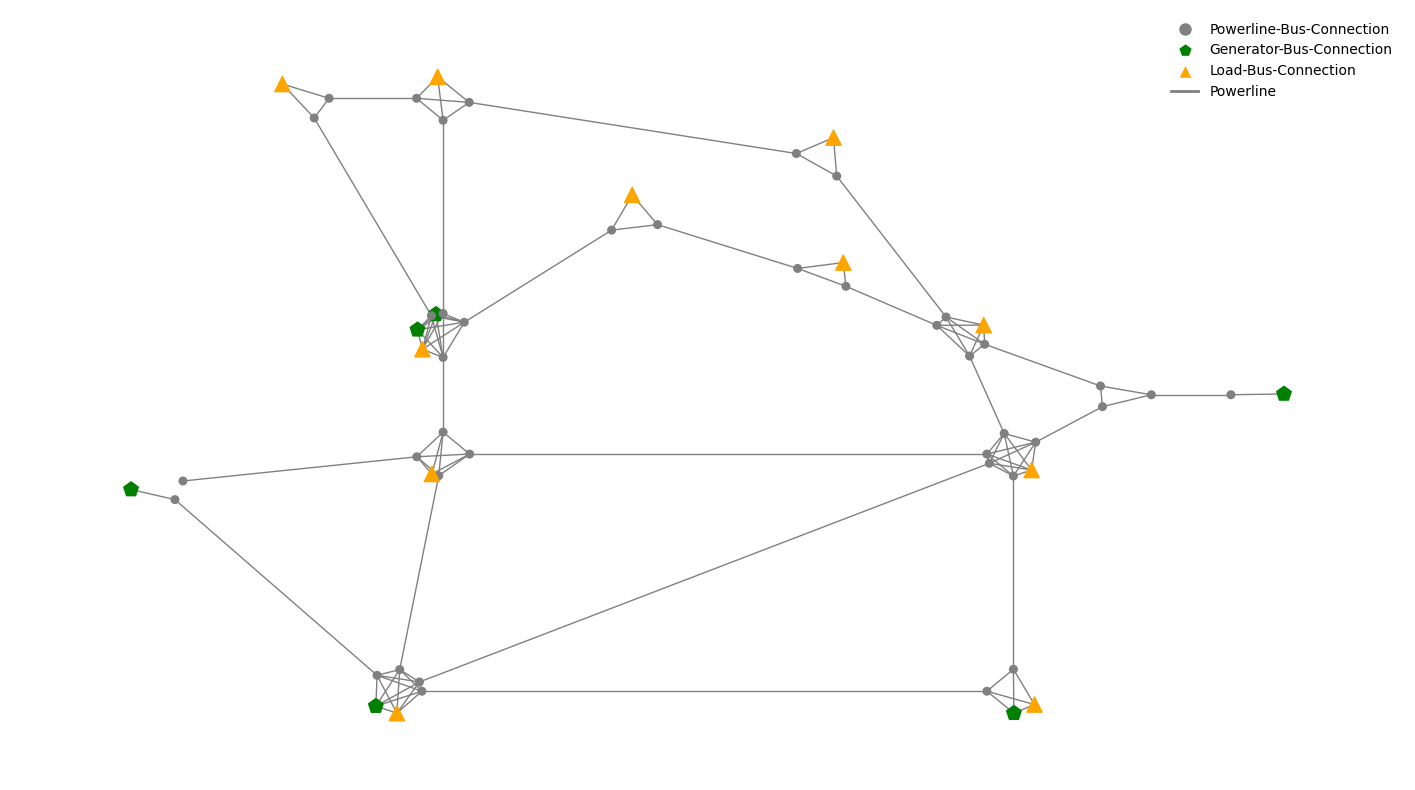

In [8]:
obs, _, _, _, _ = graph_env.step(2)
print(f"Shape: {obs[EDGE_MASK].shape}")
print(obs[EDGE_MASK])

edge_index = obs[EDGE_INDEX][:,obs[EDGE_MASK]]
plotting_args = PlottingArgs(
    num_nodes=obs_space.num_nodes,
    powerline_edge_index=edge_index,
    node_styles=get_node_styles(env, obs_space.__class__)
)
fig = visualize_graph(plotting_args)
fig.show()

Note that the leftmost substation is no longer fully connected.

# 36 Nodes grid

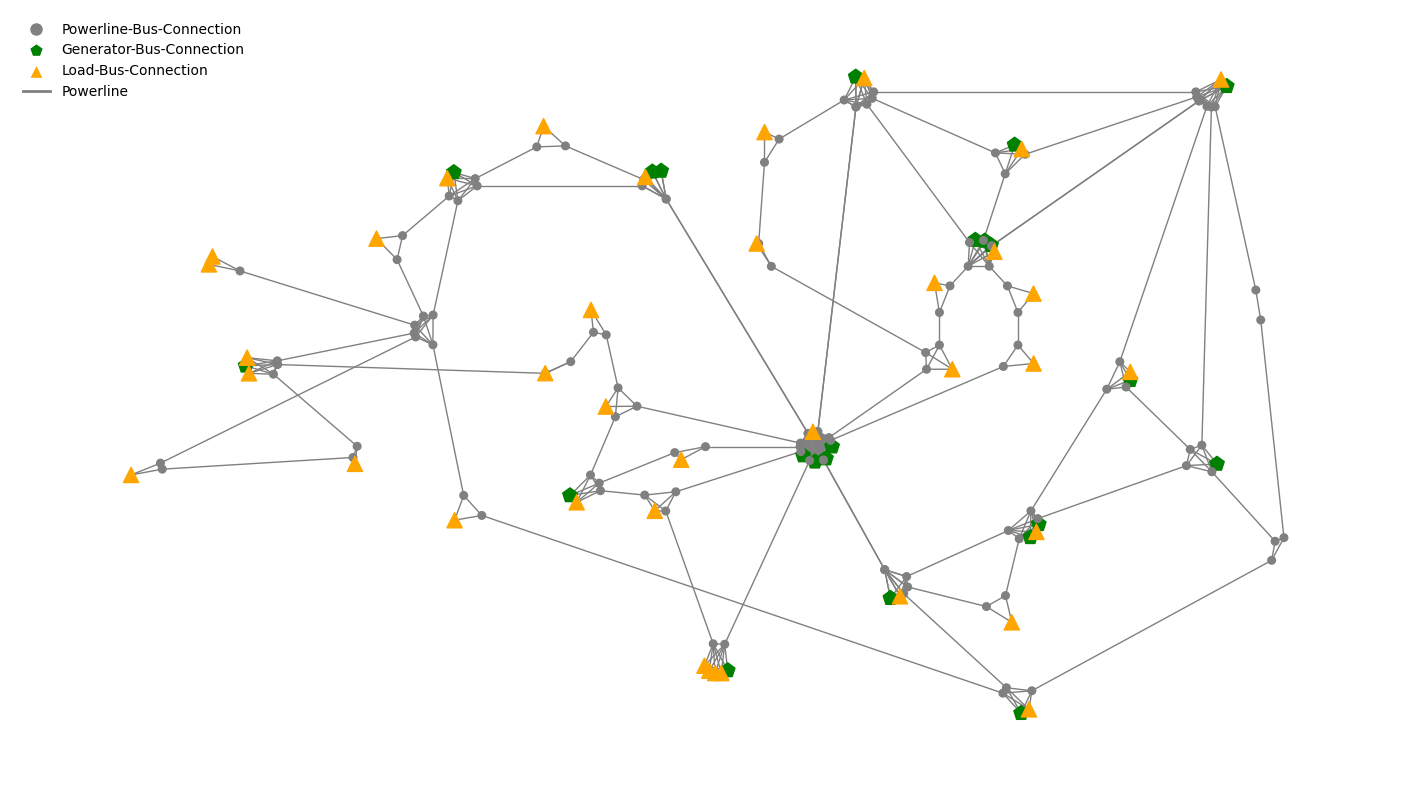

In [9]:
env_36 = grid2op.make("l2rpn_wcci_2020")
g2op_obs_36 = env_36.reset()
obs_space_36 = BusConnectivityGraphObsSpace(env_36.observation_space)
edge_index_36 = obs_space_36.to_gym(g2op_obs_36)[EDGE_INDEX]
plotting_args_36 = PlottingArgs(
    num_nodes=obs_space_36.num_nodes,
    powerline_edge_index=edge_index_36,
    node_styles=get_node_styles(env_36, obs_space_36.__class__)
)
fig_36 = visualize_graph(plotting_args_36)
fig_36.show()

# 118 Nodes grid

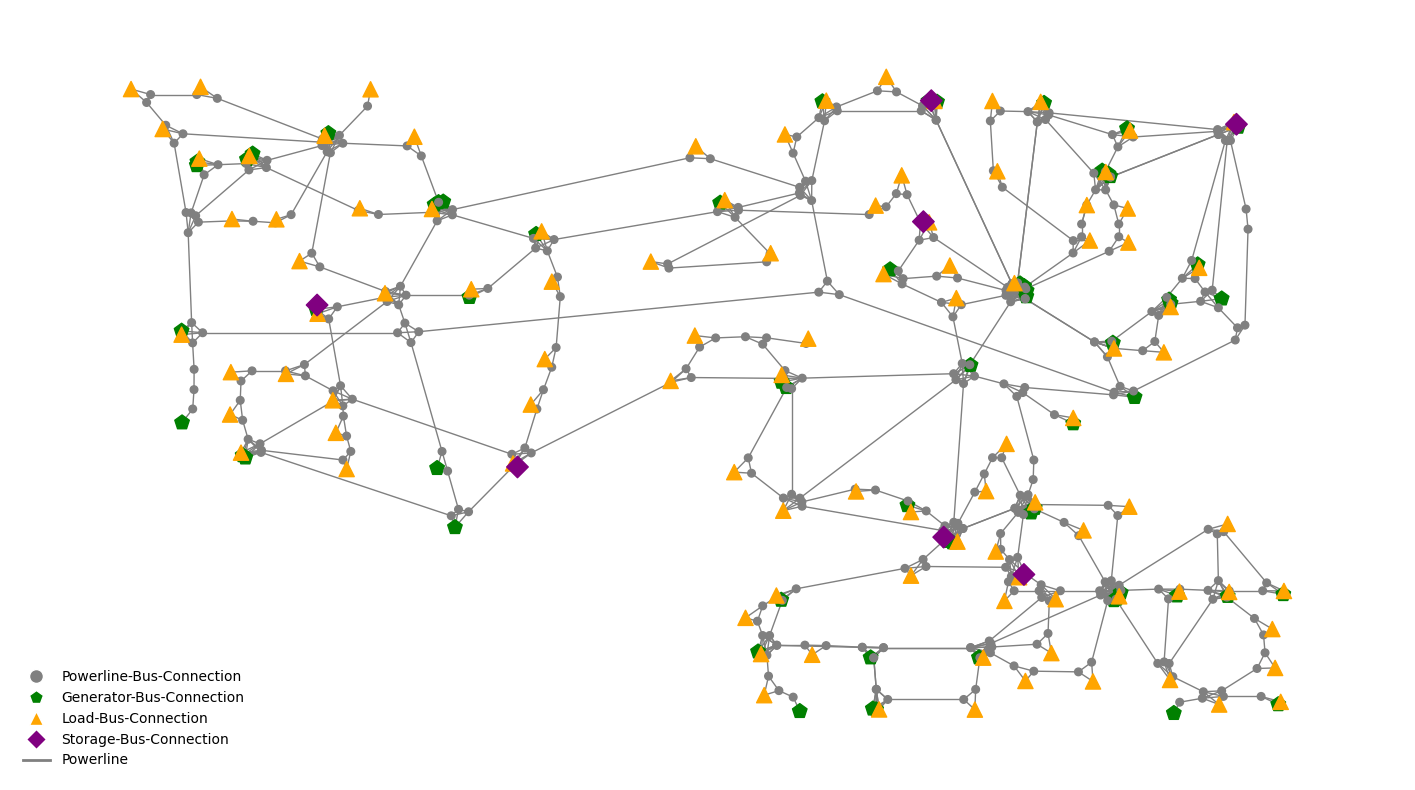

In [10]:
env_118 = grid2op.make("l2rpn_idf_2023")
g2op_obs_118 = env_118.reset()
obs_space_118 = BusConnectivityGraphObsSpace(env_118.observation_space)
edge_index_118 = obs_space_118.to_gym(g2op_obs_118)[EDGE_INDEX]
plotting_args_18 = PlottingArgs(
    num_nodes=obs_space_118.num_nodes,
    powerline_edge_index=edge_index_118,
    node_styles=get_node_styles(env_118, obs_space_118.__class__)
)
fig_118 = visualize_graph(plotting_args_18)
fig_118.show()

[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


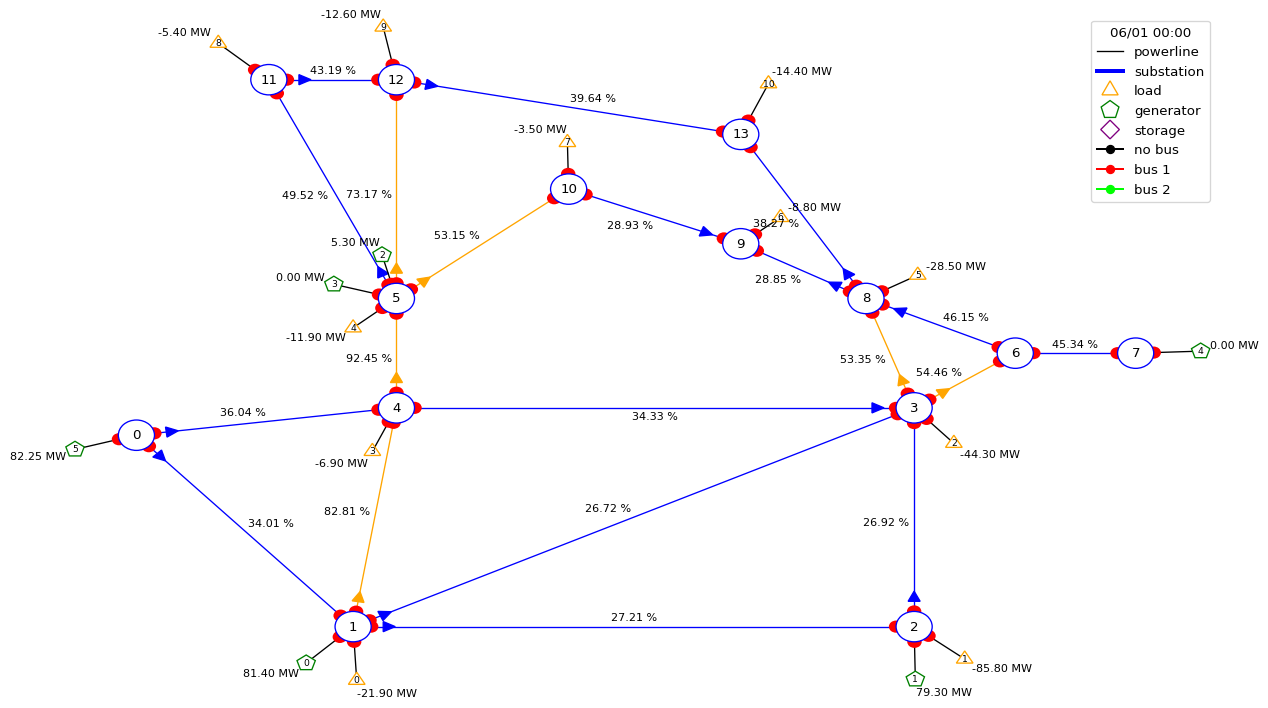

In [3]:
from matplotlib import pyplot as plt
import grid2op
plt.style.use("default")

from src.visualization import visualize_graph, get_node_styles, PlottingArgs
from src.common.observation_space import BusConnectivityGraphObsSpace, EDGE_INDEX

env_name = "l2rpn_case14_sandbox"
env = grid2op.make(env_name)
obs = env.reset()

# --- Left: Grid2Op renderer, captured as an RGB array ---
env.attach_renderer()
rgb = env.render("silent", )
print(rgb)

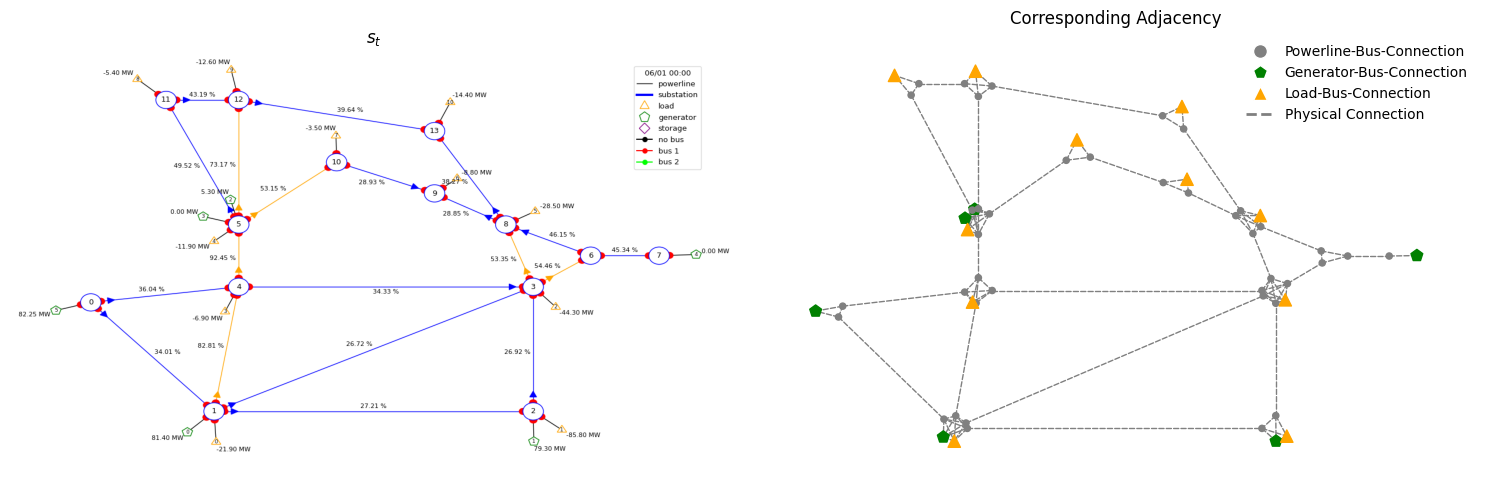

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# --- Right: Your graph-based visualization of the SAME obs ---
obs_space = BusConnectivityGraphObsSpace(env.observation_space)
gym_obs = obs_space.to_gym(obs)
edge_index = gym_obs[EDGE_INDEX]

plotting_args = PlottingArgs(
    num_nodes=obs_space.num_nodes,
    powerline_edge_index=edge_index,
    node_styles=get_node_styles(env, obs_space.__class__),
)
axs[0].imshow(rgb)
axs[0].set_title(r"$s_t$")
axs[0].axis("off")
visualize_graph(plotting_args, ax=axs[1])
axs[1].set_title("Corresponding Adjacency")

plt.tight_layout()
plt.show()
